# Bayes Factor Simulations
The purpose of this notebook is primarily to see how well a random goal selection model is distinguishable from the other two models. The main concern right now is that data from a truly random agent might be difficult to distinguish from a random agent. For that reason will simulate data from a random goal selection agent, and then do model fitting to see how well we are able to distinguish the models from one another. 

## Todo
* Disable double goal sampling

In [169]:
from rllib.shapeworld import State, Action, ShapeWorld, GoalWorld, Shape
from rllib.mdp import MDPPolicy, MarkovDecisionProcess
from typing import Sequence, Hashable, TypeVar, Generic
from random import Random
from scipy.optimize import minimize
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


# Program the agents

## Program Abstract Agent


In [ ]:
S = TypeVar('S', bound=Hashable)  # Generic State type
A = TypeVar('A', bound=Hashable)  # Generic Action type

class GoalSelectionPolicy(Generic[S, A]):
    def __init__(self, mdp: MarkovDecisionProcess[S, A]):
        '''Initialize the policy with the MDP.'''
        self.mdp = mdp
        self.state_space = mdp.state_space

    def sample_action(self, s : S, rng : Random) -> tuple[A, float]:
        '''Uses some policy to select which goal to select.'''
        raise NotImplementedError
    
    def calc_log_lik(self, states : Sequence[S]) -> np.ndarray:
        '''Calculate the log likelihood of selecting a particular state.'''
        raise NotImplementedError
    
    def reset(self):
        raise NotImplementedError



## Program the random goal selection agent

In [136]:
class RandomGoalSelectionPolicy(GoalSelectionPolicy[S, A]):
    def __init__(self, mdp: MarkovDecisionProcess[S, A]):
        super().__init__(mdp)
        self.num_params = 0

    def sample_action(self, s : S, rng : Random) -> S:
        '''Randomly selects a goal from the state space of the MDP.'''
        return rng.choice(self.state_space)
    
    #TODO: change to log_lik
    def neg_log_lik(self, states : Sequence[S]) -> np.ndarray:
        '''Calculate the log likelihood of selecting a particular state.'''
        return - np.log(1 / len(self.state_space)) * np.ones(len(states))
    
    '''
    def calc_BIC(self, states : Sequence[S]) -> float:
        Calculate the BIC for the model.
        log_lik = self.neg_log_lik(states)
        return -2 * log_lik + self.num_params * np.log(len(self.state_space))
    '''
    
    def calc_BIC(self, states: Sequence[S]) -> float:
        '''Calculate the BIC for the model.'''
        # Get total log likelihood by summing individual log likelihoods
        n_log_lik = np.sum(self.neg_log_lik(states))
        # No parameter penalty since num_params = 0
        return 2 * n_log_lik  # Returns a single float
    
    def reset(self):
        pass
    

## Program the conceptual selection agent

In [137]:
class ConceptualGoalSelectionPolicy(GoalSelectionPolicy[S, A]):
    def __init__(self, mdp: MarkovDecisionProcess[S, A], pcfg_probs: pd.DataFrame):
        super().__init__(mdp)
        self.num_params = 1
        self.pcfg_probs = pcfg_probs
        self.beta = 1.0
        
        # Pre-compute numpy array of log probabilities
        self.log_probs = self.pcfg_probs['log_probability'].values
        
        # Pre-compute state objects and store as numpy array
        self.state_cache = np.array([
            State(
                shape1=Shape(sides=row['shape1_sides'], 
                           shade=row['shape1_shade'], 
                           texture=row['shape1_texture']),
                shape2=Shape(sides=row['shape2_sides'], 
                           shade=row['shape2_shade'], 
                           texture=row['shape2_texture']),
                shape3=Shape(sides=row['shape3_sides'], 
                           shade=row['shape3_shade'], 
                           texture=row['shape3_texture'])
            )
            for _, row in pcfg_probs.iterrows()
        ])
        
        # Cache for softmax probabilities
        self._cached_beta = None
        self._cached_probs = None
        
        # For faster random sampling
        self._cached_cumsum = None
    
    def _compute_probs(self, beta: float) -> np.ndarray:
        '''Compute softmax probabilities and cumulative sum for fast sampling.'''
        log_probs_shifted = beta * (self.log_probs - np.max(self.log_probs))
        exp_values = np.exp(log_probs_shifted)
        probs = exp_values / np.sum(exp_values)
        return probs, np.cumsum(probs)
    
    def sample_action(self, s: S, rng: Random, beta: float = None) -> A:
        '''Sample an action using softmax over PCFG log probabilities.'''
        if beta is None:
            beta = self.beta
            
        # Update probability cache if beta changed
        if beta != self._cached_beta:
            self._cached_probs, self._cached_cumsum = self._compute_probs(beta)
            self._cached_beta = beta
        
        # Fast random sampling using cumulative sum
        r = rng.random()
        chosen_idx = np.searchsorted(self._cached_cumsum, r)
        
        # Return pre-computed state
        return self.state_cache[chosen_idx]
    
    def _state_to_key(self, state: State) -> tuple:
        '''Convert a state object to a tuple of features for DataFrame lookup.'''
        
        return (
            state.shape1.sides, state.shape1.shade, state.shape1.texture,
            state.shape2.sides, state.shape2.shade, state.shape2.texture,
            state.shape3.sides, state.shape3.shade, state.shape3.texture
        )
    
    def neg_log_lik(self, beta: float, states: Sequence[S]) -> np.ndarray:
        '''Calculate the log likelihood of selecting an array of states.'''
        
        if beta is None:
            beta = self.beta

        # Update probability cache if beta changed
        if beta != self._cached_beta:
            self._cached_probs, self._cached_cumsum = self._compute_probs(beta)
            self._cached_beta = beta

        # Create lookup dictionary if it doesn't exist
        if not hasattr(self, '_state_to_idx'):
            self._state_to_idx = {
                tuple(row[['shape1_sides', 'shape1_shade', 'shape1_texture',
                        'shape2_sides', 'shape2_shade', 'shape2_texture',
                        'shape3_sides', 'shape3_shade', 'shape3_texture']]): i 
                for i, row in self.pcfg_probs.iterrows()
            }

        # Convert states to indices
        state_keys = [self._state_to_key(s) for s in states]
        indices = [self._state_to_idx[k] for k in state_keys]
        
        # Get log probabilities using indices
        log_probs = self.log_probs[indices]

        return -log_probs
    
    def sum_nll(self, beta: float, states: Sequence[S]) -> float:
        '''Sum the negative log likelihood of selecting an array of states.'''
        return np.sum(self.neg_log_lik(beta, states))
    
    def max_lik_estimate(self, states : Sequence[S]) -> float:
        '''Use MLE to estimate the beta parameter using scipy.optimize.minimize.'''

        # we will minimize 5 times, and will take the best of those 5 starts
        initial_conds = np.random.uniform(low=1, high=10, size=5) # we must feed the minimizer some initial conditions
        bounds = [(0.001, None)] # the bounds for inverse tempurature are (0, inf)
        best_result = None
        best_nll = np.inf

        # minimize for each of the generated intial conditions
        for initial_cond in initial_conds:
            result = minimize(
                self.sum_nll, # find the parameter that minimizes negloglik
                args=(states,), # this is always passed as a tuple
                x0 = [initial_cond], # initial conditions
                bounds=bounds, # the space to search with the minimization function
                method='L-BFGS-B' # the minimization method. More options out there is this doesn't work well.
            )

            # take the best minimization so far
            if result.success and result.fun < best_nll:
                best_result = result
                best_nll = result.fun

        if best_result is None:
                raise RuntimeError("Optimization failed from all starting points")
        
        self.beta = best_result.x[0]
        self._cached_beta = best_result.x[0]
        self._cached_probs, self._cached_cumsum = self._compute_probs(best_result.x[0])
        return best_result.x[0], best_result.fun # best inv temp, best nll

    def calc_BIC(self, states : Sequence[S]) -> float:
        '''
        Calculate the BIC for the model with MLE estimate of beta
        '''

        beta, nll = self.max_lik_estimate(states)
        return 2 * nll + self.num_params * np.log(len(states))
    
    def reset(self):
        self._cached_beta = None
        self._cached_probs = None
        self._cached_cumsum = None
        

In [187]:
class ConceptualGoalSelectionPolicy(GoalSelectionPolicy[S, A]):
    def __init__(self, mdp: MarkovDecisionProcess[S, A], pcfg_probs: pd.DataFrame):
        super().__init__(mdp)
        self.num_params = 1
        self.pcfg_probs = pcfg_probs
        self.beta = 7.0
        
        # Pre-compute numpy array of log probabilities
        self.log_probs = self.pcfg_probs['log_probability'].values
        
        # Pre-compute state objects and store as numpy array
        self.state_cache = np.array([
            State(
                shape1=Shape(sides=row['shape1_sides'], 
                           shade=row['shape1_shade'], 
                           texture=row['shape1_texture']),
                shape2=Shape(sides=row['shape2_sides'], 
                           shade=row['shape2_shade'], 
                           texture=row['shape2_texture']),
                shape3=Shape(sides=row['shape3_sides'], 
                           shade=row['shape3_shade'], 
                           texture=row['shape3_texture'])
            )
            for _, row in pcfg_probs.iterrows()
        ])
        
        # Cache for softmax probabilities
        self._cached_beta = None
        self._cached_probs = None
        
        # For faster random sampling
        self._cached_cumsum = None
    
    def _compute_probs(self, beta: float) -> np.ndarray:
        '''Compute softmax probabilities and cumulative sum for fast sampling.'''
        log_probs_shifted = beta * (self.log_probs - np.max(self.log_probs))
        exp_values = np.exp(log_probs_shifted)
        probs = exp_values / np.sum(exp_values)
        return probs, np.cumsum(probs)
    
    def sample_action(self, s: S, rng: Random, beta: float = None) -> A:
        '''Sample an action using softmax over PCFG log probabilities.'''
        if beta is None:
            beta = self.beta
            
        # Update probability cache if beta changed
        if beta != self._cached_beta:
            self._cached_probs, self._cached_cumsum = self._compute_probs(beta)
            self._cached_beta = beta
        
        # Fast random sampling using cumulative sum
        r = rng.random()
        chosen_idx = np.searchsorted(self._cached_cumsum, r)
        
        # Return pre-computed state
        return self.state_cache[chosen_idx]
    
    def _state_to_key(self, state: State) -> tuple:
        '''Convert a state object to a tuple of features for DataFrame lookup.'''
        
        return (
            state.shape1.sides, state.shape1.shade, state.shape1.texture,
            state.shape2.sides, state.shape2.shade, state.shape2.texture,
            state.shape3.sides, state.shape3.shade, state.shape3.texture
        )
    
    def neg_log_lik(self, beta: float, states: Sequence[S]) -> np.ndarray:
        '''Calculate the log likelihood of selecting an array of states.'''
        
        if beta is None:
            beta = self.beta

        # Update probability cache if beta changed
        if beta != self._cached_beta:
            self._cached_probs, self._cached_cumsum = self._compute_probs(beta)
            self._cached_beta = beta

        # Create lookup dictionary if it doesn't exist
        if not hasattr(self, '_state_to_idx'):
            self._state_to_idx = {
                tuple(row[['shape1_sides', 'shape1_shade', 'shape1_texture',
                        'shape2_sides', 'shape2_shade', 'shape2_texture',
                        'shape3_sides', 'shape3_shade', 'shape3_texture']]): i 
                for i, row in self.pcfg_probs.iterrows()
            }

        # Convert states to indices
        state_keys = [self._state_to_key(s) for s in states]
        indices = [self._state_to_idx[k] for k in state_keys]
        
        # Get log probabilities using indices
        log_probs = self.log_probs[indices]

        return -log_probs
    
    def sum_nll(self, beta: float, states: Sequence[S]) -> float:
        '''Sum the negative log likelihood of selecting an array of states.'''
        return np.sum(self.neg_log_lik(beta, states))
    
    def sum_nll_with_prior(self, beta: float, states: Sequence[S]) -> float:
        '''Sum the negative log likelihood plus the negative log prior (for MAP estimation).'''
        # Get negative log likelihood
        nll = self.sum_nll(beta, states)
        
        # Add negative log prior (gamma distribution)
        alpha = 5.0  # shape parameter (higher values push the mode higher)
        theta = 1.0  # scale parameter (higher values spread the distribution out)
        
        # Negative log of gamma pdf (dropping constant terms)
        neg_log_prior = -((alpha - 1) * np.log(beta)) + (beta / theta)
        
        return nll + neg_log_prior
    
    def max_posterior_estimate(self, states: Sequence[S]) -> tuple[float, float]:
        '''Use MAP to estimate the beta parameter using scipy.optimize.minimize.'''
        # We will minimize 5 times, and will take the best of those 5 starts
        initial_conds = np.random.uniform(low=1, high=10, size=5)
        bounds = [(0.001, None)]  # The bounds for inverse temperature are (0, inf)
        best_result = None
        best_nlp = np.inf  # negative log posterior
        
        # Minimize for each of the generated initial conditions
        for initial_cond in initial_conds:
            result = minimize(
                self.sum_nll_with_prior,  # Find parameter that minimizes neg log posterior
                args=(states,),
                x0=[initial_cond],
                bounds=bounds,
                method='L-BFGS-B'
            )
            
            # Take the best minimization so far
            if result.success and result.fun < best_nlp:
                best_result = result
                best_nlp = result.fun
                
        if best_result is None:
            raise RuntimeError("Optimization failed from all starting points")
            
        self.beta = best_result.x[0]
        self._cached_beta = best_result.x[0]
        self._cached_probs, self._cached_cumsum = self._compute_probs(best_result.x[0])
        return best_result.x[0], best_result.fun
    
    def calc_BIC(self, states: Sequence[S]) -> float:
        '''Calculate the BIC for the model with MAP estimate of beta'''
        # Note: We still use the likelihood term (not posterior) for BIC
        beta, nlp = self.max_posterior_estimate(states)
        nll = self.sum_nll(beta, states)  # Get just the likelihood term
        return 2 * nll + self.num_params * np.log(len(states))

    def reset(self):
        self._cached_beta = None
        self._cached_probs = None
        self._cached_cumsum = None

## Program the optimal selection agent

# Make Simulation Result Class


In [18]:
class GoalSimulationResult:
    def __init__(self, goals : np.ndarray):
        self.goals = goals

# Simulate and Fit Data

In [87]:
def run_strategy(
    *,
    policy : GoalSelectionPolicy[S, A],
    n_trials : int,
    n_episodes : int,
    seed : int
) -> GoalSimulationResult:
    # Set the random seed
    rng = random.Random(seed)
    np.random.seed(rng.randint(0, 2**32 - 1))

    # Initialize arrays to store State choices for each episode
    goals = np.zeros((n_episodes, n_trials), dtype=object)

    # Run n_episodes episodes
    for ep in range(n_episodes):
        policy.reset()
        for step in range(n_trials):
            a = policy.sample_action(rng=rng, s=None)
            goals[ep, step] = a

    return GoalSimulationResult(goals)

## Random as True Agent

In [192]:
# Choose an arbitrary goal and discount rate
goal = State(shape1=Shape(sides='circle', shade='low', texture='plain'),
             shape2=Shape(sides='square', shade='medium', texture='stripes'),
             shape3=Shape(sides='triangle', shade='high', texture='dots'))
shape_world = ShapeWorld(goal=goal, discount_rate=0.99)

# Set the number of episodes and trials
n_episodes = 10000
n_trials = 20

# Create the agents
random_agent = RandomGoalSelectionPolicy(shape_world)
pcfg_probs = pd.read_csv('pcfg_probabilities.csv')
conceptual_agent = ConceptualGoalSelectionPolicy(shape_world, pcfg_probs)

# Simulate 10000 episodes of 20 trials each of the random agent
selection = run_strategy(policy=random_agent, 
                         n_trials=n_trials, 
                         n_episodes=n_episodes, 
                         seed=4242)

# Calculate BIC differences for each episode
bic_diffs = []
for i in tqdm(range(n_episodes)):
    random_bic = random_agent.calc_BIC(states=selection.goals[i])
    conceptual_bic = conceptual_agent.calc_BIC(states=selection.goals[i])
    bic_diff = conceptual_bic - random_bic  # Positive means random model is favored
    bic_diffs.append(bic_diff)

print(bic_diffs)


100%|██████████| 10000/10000 [08:55<00:00, 18.69it/s]  

[1.6598292280764326, 8.886872341909395, 2.822981243890979, 5.437992639676224, 6.288780622924662, 6.869256336798401, 4.446691392476225, 12.384823607991223, 11.878923135143054, 10.08112726594976, 6.33336823373935, 12.393251263401112, 4.88917206676507, 7.057375104986818, 11.07468079035965, 13.975927100347462, 9.467281015126503, 5.688780954765605, 3.748525553479226, 8.553292081869756, 6.39008717953277, 10.667126063120008, 6.502833809365086, 4.879854555175427, 9.861001787259, 12.499271667975734, 5.904750352258247, 2.4899855053690203, 7.499294084691883, 6.593415285073718, 10.275051696029038, 0.1318763996698067, 7.3432238299567985, 5.8562784045089415, 12.147915845550983, 5.638775267947096, 4.504314442338625, 11.81907488526116, 5.577659891623796, 9.235468101790104, 1.9513510666454295, 6.265767386147161, -0.5862895882326598, 6.1817557273549255, 0.14128548597335566, 7.326230521576292, 6.293353829653313, 14.50006584156057, 9.327253279988781, 13.225549188381024, 8.555321130477978, 6.89996057649767

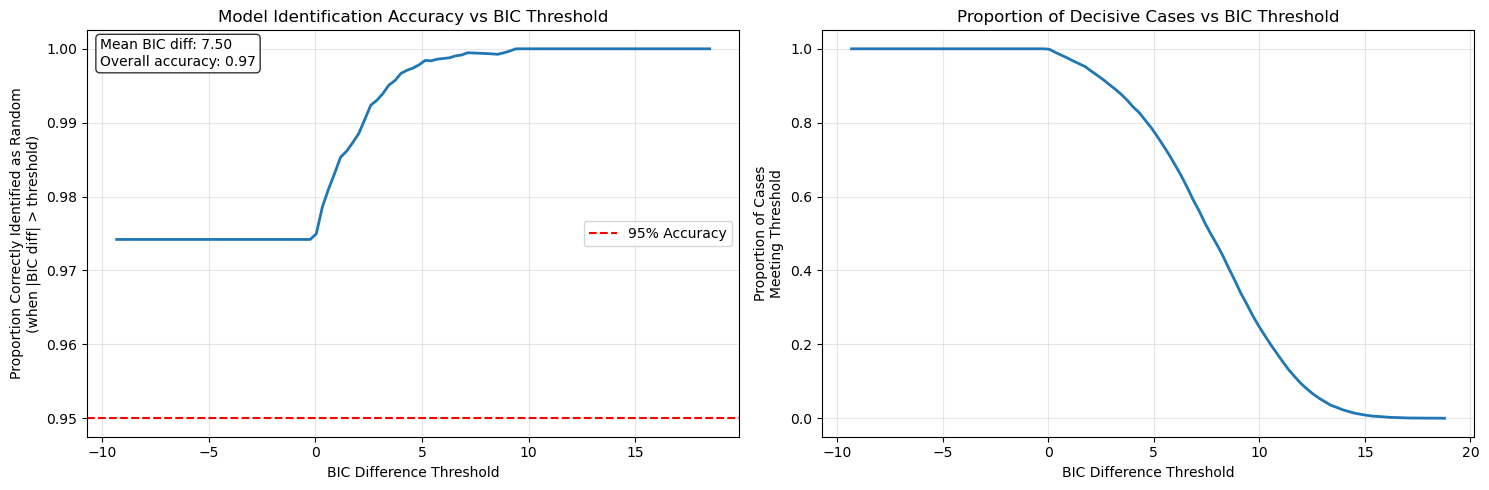

In [193]:
# Convert BIC differences to numpy array
bic_diffs = np.array(bic_diffs)

# Create thresholds from minimum to maximum BIC difference
thresholds = np.linspace(min(bic_diffs), max(bic_diffs), 100)
accuracies = []

# For each threshold, calculate proportion of correct identifications
for threshold in thresholds:
    # For random as true model:
    # - BIC diff > threshold indicates correct identification (favors random)
    # - Only consider cases where |BIC diff| > threshold
    decisive_cases = np.abs(bic_diffs) > threshold
    if np.sum(decisive_cases) > 0:
        accuracy = np.mean(bic_diffs[decisive_cases] > 0)
        accuracies.append(accuracy)
    else:
        accuracies.append(np.nan)

# Calculate proportion of cases meeting each threshold
proportions_meeting_threshold = [np.mean(np.abs(bic_diffs) > t) for t in thresholds]

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Accuracy vs Threshold
ax1.plot(thresholds, accuracies, '-', linewidth=2)
ax1.axhline(y=0.95, color='r', linestyle='--', label='95% Accuracy')
ax1.set_xlabel('BIC Difference Threshold')
ax1.set_ylabel('Proportion Correctly Identified as Random\n(when |BIC diff| > threshold)')
ax1.set_title('Model Identification Accuracy vs BIC Threshold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='center right')

# Plot 2: Proportion of Cases Meeting Threshold
ax2.plot(thresholds, proportions_meeting_threshold, '-', linewidth=2)
ax2.set_xlabel('BIC Difference Threshold')
ax2.set_ylabel('Proportion of Cases\nMeeting Threshold')
ax2.set_title('Proportion of Decisive Cases vs BIC Threshold')
ax2.grid(True, alpha=0.3)

# Add text box with summary statistics
ax1.text(0.02, 0.98, 
         f'Mean BIC diff: {np.mean(bic_diffs):.2f}\n'
         f'Overall accuracy: {np.mean(bic_diffs > 0):.2f}',
         transform=ax1.transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

## Conceptual as True Agent

In [188]:
# Choose an arbitrary goal and discount rate
goal = State(shape1=Shape(sides='circle', shade='low', texture='plain'),
             shape2=Shape(sides='square', shade='medium', texture='stripes'),
             shape3=Shape(sides='triangle', shade='high', texture='dots'))
shape_world = ShapeWorld(goal=goal, discount_rate=0.99)

# Set the number of episodes and trials
n_episodes = 10000
n_trials = 20

# Create the agents
random_agent = RandomGoalSelectionPolicy(shape_world)
pcfg_probs = pd.read_csv('pcfg_probabilities.csv')
conceptual_agent = ConceptualGoalSelectionPolicy(shape_world, pcfg_probs)

# Simulate episodes using the conceptual agent as the true model
selection = run_strategy(policy=conceptual_agent, 
                        n_trials=n_trials, 
                        n_episodes=n_episodes, 
                        seed=42)

# Calculate BIC differences for each episode
bic_diffs = []
for i in tqdm(range(n_episodes)):
    random_bic = random_agent.calc_BIC(states=selection.goals[i])
    conceptual_bic = conceptual_agent.calc_BIC(states=selection.goals[i])
    bic_diff = random_bic - conceptual_bic  # Positive means conceptual model is favored
    bic_diffs.append(bic_diff)

# Convert BIC differences to numpy array
bic_diffs = np.array(bic_diffs)


100%|██████████| 10000/10000 [02:20<00:00, 71.01it/s]


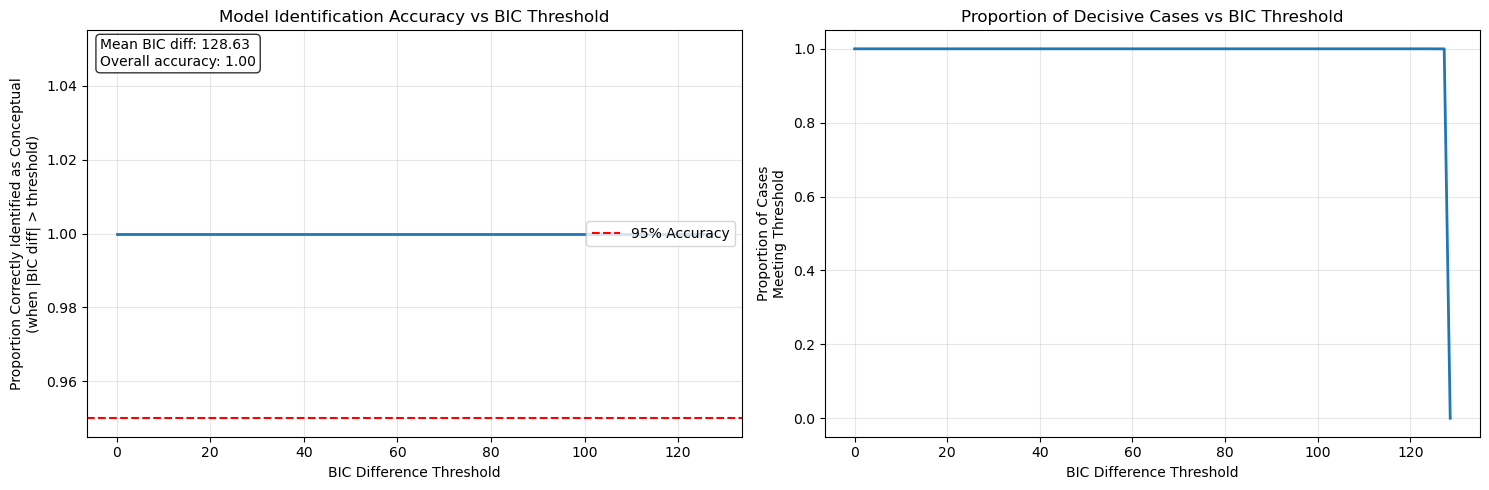

In [191]:

# Create thresholds from minimum to maximum BIC difference
thresholds = np.linspace(0, max(bic_diffs), 100)
accuracies = []

# For each threshold, calculate proportion of correct identifications
for threshold in thresholds:
    # For conceptual as true model:
    # - BIC diff > threshold indicates correct identification (favors conceptual)
    # - Only consider cases where |BIC diff| > threshold
    decisive_cases = np.abs(bic_diffs) > threshold
    if np.sum(decisive_cases) > 0:
        accuracy = np.mean(bic_diffs[decisive_cases] > 0)
        accuracies.append(accuracy)
    else:
        accuracies.append(np.nan)

# Calculate proportion of cases meeting each threshold
proportions_meeting_threshold = [np.mean(np.abs(bic_diffs) > t) for t in thresholds]

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Accuracy vs Threshold
ax1.plot(thresholds, accuracies, '-', linewidth=2)
ax1.axhline(y=0.95, color='r', linestyle='--', label='95% Accuracy')
ax1.set_xlabel('BIC Difference Threshold')
ax1.set_ylabel('Proportion Correctly Identified as Conceptual\n(when |BIC diff| > threshold)')
ax1.set_title('Model Identification Accuracy vs BIC Threshold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='center right')

# Plot 2: Proportion of Cases Meeting Threshold
ax2.plot(thresholds, proportions_meeting_threshold, '-', linewidth=2)
ax2.set_xlabel('BIC Difference Threshold')
ax2.set_ylabel('Proportion of Cases\nMeeting Threshold')
ax2.set_title('Proportion of Decisive Cases vs BIC Threshold')
ax2.grid(True, alpha=0.3)

# Add text box with summary statistics
ax1.text(0.02, 0.98, 
         f'Mean BIC diff: {np.mean(bic_diffs):.2f}\n'
         f'Overall accuracy: {np.mean(bic_diffs > 0):.2f}',
         transform=ax1.transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()


## Optimal as True Agent